In [9]:
#什么是分词
#分词是将连续的文本切分成一个个单独的词语的过程。在自然语言处理（NLP）中，分词是一个重要的预处理步骤，因为它将文本转换为更小的单位，便于后续的分析和处理。
#分词的目的是将文本中的连续字符序列切分成一个个独立的词语，以便于后续的文本分析、特征提取和建模。分词的结果通常是一个词语列表，其中每个词语都是文本中的一个独立单位。

#这里利用jieba分词进行分词
import jieba
import os
os.chdir('D:/NLP')

text='北京冬奥的进度条已经过半，不少外国运动员在完成自己的比赛之后踏上归途。'
word=jieba.lcut(text) #lcut形成列表，精细模式，适合文本分析
print(word)
word1=jieba.lcut_for_search(text)
print(word1) #lcut_for_search形成列表，搜索引擎模式，适合搜索引擎构建倒排索引

#NER概念
#命名实体识别（Named Entity Recognition，NER）是自然语言处理中的一个重要任务，旨在从文本中识别出具有特定意义的实体，例如人名、地名、组织机构名等。NER的目标是将文本中的实体进行分类和标注，以便于后续的分析和处理。
#例如，在句子“北京冬奥会将在2022年举行”中，NER可以识别出“北京冬奥会”是一个组织机构名，“2022年”是一个时间实体。

#jieba分词的词性标注
#jieba分词还可以进行词性标注，即为每个词语标注其词性，例如名词、动词、形容词等。词性标注可以帮助我们更好地理解文本的语法结构和语义信息。
#例如，在句子“北京冬奥会将在2022年举行”中，jieba分词的词性标注可以标注出“北京冬奥会”是一个名词，“将在”是一个动词，“2022年”是一个名词，“举行”是一个动词。




['北京', '冬奥', '的', '进度条', '已经', '过半', '，', '不少', '外国', '运动员', '在', '完成', '自己', '的', '比赛', '之后', '踏上', '归途', '。']
['北京', '冬奥', '的', '进度', '进度条', '已经', '过半', '，', '不少', '外国', '运动', '动员', '运动员', '在', '完成', '自己', '的', '比赛', '之后', '踏上', '归途', '。']


In [18]:
#one-hot编码
#one-hot编码是一种将分类变量转换为二进制向量的编码方法。对于一个具有N个类别的分类变量，one-hot编码会将其转换为一个长度为N的二进制向量，其中只有一个位置为1，表示该类别，

#使用pytorch进行one-hot编码
import torch
import torch.nn as nn

#先利用分词器进行分词
text='北京冬奥的进度条已经过半，不少外国运动员在完成自己的比赛之后踏上归途。'
word=jieba.lcut(text)
print(word)
unique_word=list(set(word)) #去重
idx_word={i:x for i,x in enumerate(unique_word)} #构建索引到词的映射
print(idx_word)
word_idx={x:i for i,x in enumerate(unique_word)} #构建词到索引的映射
print(word_idx)

#将文本转换为索引
idx=[word_idx[w] for w in word]
print(idx)

#利用torch进行one-hot编码
one_hot=nn.functional.one_hot(torch.tensor(idx),len(unique_word)) #第一个参数为索引，转换为tensor格式，第二个参数为类别数量，是向量的长度
print(one_hot)

['北京', '冬奥', '的', '进度条', '已经', '过半', '，', '不少', '外国', '运动员', '在', '完成', '自己', '的', '比赛', '之后', '踏上', '归途', '。']
{0: '不少', 1: '踏上', 2: '比赛', 3: '，', 4: '。', 5: '运动员', 6: '的', 7: '过半', 8: '在', 9: '自己', 10: '之后', 11: '归途', 12: '冬奥', 13: '进度条', 14: '外国', 15: '北京', 16: '完成', 17: '已经'}
{'不少': 0, '踏上': 1, '比赛': 2, '，': 3, '。': 4, '运动员': 5, '的': 6, '过半': 7, '在': 8, '自己': 9, '之后': 10, '归途': 11, '冬奥': 12, '进度条': 13, '外国': 14, '北京': 15, '完成': 16, '已经': 17}
[15, 12, 6, 13, 17, 7, 3, 0, 14, 5, 8, 16, 9, 6, 2, 10, 1, 11, 4]
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 

In [19]:
#word2vec
#word2vec是一种将词语转换为向量表示的技术。它通过训练一个神经网络模型来学习词语之间的关系和语义信息，从而将每个词语映射到一个固定长度的向量空间中。word2vec的核心思想是通过上下文信息来学习词语的向量表示，使得相似的词语在向量空间中距离更近。
#word2vec的训练方法主要有两种：连续词袋模型（CBOW）和跳字模型（Skip-gram）。CBOW模型通过上下文词语来预测中心词语，而Skip-gram模型则通过中心词语来预测上下文词语。

#CBOW模型原理
#CBOW模型的基本思想是通过上下文词语来预测中心词语。具体来说，CBOW模型将上下文词语的向量表示进行平均或加权平均，然后通过一个全连接层将其映射到中心词语的向量表示上。训练过程中，CBOW模型会根据预测的中心词语与实际中心词语之间的误差来更新模型参数，从而学习到词语之间的关系和语义信息。
#CBOW模型有两个权重矩阵：输入权重矩阵和输出权重矩阵。输入权重矩阵用于将上下文词语的索引转换为向量表示，即词向量，输出权重矩阵用于将中心词语的向量表示转换为预测的中心词语的概率分布。
#反向传播时，CBOW模型会根据预测的中心词语与实际中心词语之间的误差来更新输入权重矩阵和输出权重矩阵，从而学习到词语之间的关系和语义信息。

#skipgram模型原理
#Skip-gram模型的基本思想是通过中心词语来预测上下文词语。具体来说，Skip-gram模型将中心词语的向量表示通过一个全连接层映射到上下文词语的向量表示上，然后通过一个softmax函数将其转换为预测的上下文词语的概率分布。
#Skip-gram模型也有两个权重矩阵：输入权重矩阵和输出权重矩阵。输入权重矩阵用于将中心词语的索引转换为向量表示，即词向量，输出权重矩阵用于将上下文词语的向量表示转换为预测的上下文词语的概率分布。
#反向传播时，Skip-gram模型会根据预测的上下文词语与实际上下文词语之间的误差来更新输入权重矩阵和输出权重矩阵，从而学习到词语之间的关系和语义信息。

#第一层叫做词嵌入层，第二层是全连接层，输入是上下文词语的词向量，输出是中心词语的概率分布，第一层会生成词向量，第二层会根据词向量来预测中心词语的概率分布。

#word2vec的训练流程：
#1.准备训练数据：从文本中提取上下文词语和中心词语的索引对，构建训练数据集。
#2.训练词向量
#3.模型超参数设定
#4.模型效果检验
#5.模型的保存与加载


In [ ]:
#训练词向量
import fasttext
model=fasttext.train_unsupervised('./data/content',model='skipgram',epoch=1,verbose=2) #train_unsupervised函数用于训练无监督的词向量模型，第一个参数是文本文件的路径，第二个参数是模型类型，可以选择'skipgram'或'cbow'
#保存词向量
model.save_model('./data/content.bin') #save_model函数用于保存训练好的模型，第一个参数是保存的文件路径，第二个参数是保存的格式，可以选择bin或txt

#模型加载
model1=fasttext.load_model('./data/content.bin')
#获取词向量
vec=model1.get_word_vector('the')
print(vec)
print(vec.dtype)
print(vec.shape)




In [7]:
#word2vec和nn.embedding的区别
#1. 模型结构不同：word2vec是一种特定的模型结构，而nn.embedding是一种通用的层，可以用于构建各种不同的模型结构。
#2. 训练方式不同：word2vec通常使用无监督的方式进行训练，而nn.embedding可以使用有监督的方式进行训练，例如在文本分类任务中，nn.embedding可以与其他层一起训练，以优化整个模型的性能。
#3. 词向量的获取方式不同：word2vec通过训练一个神经网络模型来学习词向量，而nn.embedding通过一个查找表来获取词向量，即直接将词的索引映射到对应的词向量。
#4.word2vec是静态的词向量，即每个词语对应一个固定的向量表示，而nn.embedding可以是动态的词向量，即在训练过程中可以根据上下文信息动态地调整词向量的表示。


#embedding示例
import torch
import torch.nn as nn
import jieba
text1='我喜欢自然语言处理。'
text2='自然语言处理是人工智能的一个分支。'
texts=[text1,text2]
words=[]
unique_words=[]
for text in texts:
    word=jieba.lcut(text)
    words.append(word)
    for w in word:
        unique_words.append(w)
unique_words=list(set(unique_words)) #建立词表
print(words)
print(unique_words)

word_idx={w:i for i,w in enumerate(unique_words)}
print(word_idx)
idx=[]
for word in words:
    idx.extend([word_idx[w] for w in word]) #将每个词语的索引添加到索引序列中
    # idx.append(word_idx['<pad>'])
print(idx) #建立索引序列

#使用nn.embedding
embed=nn.Embedding(len(unique_words),100) #第一个参数为词表的大小，第二个参数为词向量的长度
#将idx转换为tensor
idx_tensor=torch.tensor(idx)
embedding=embed(idx_tensor) #进行词嵌入
target='自然语言'
target_idx=word_idx[target]
vec=embed(torch.tensor([target_idx])) #查找目标词向量
print(vec)
print(vec.shape)




    



[['我', '喜欢', '自然语言', '处理', '。'], ['自然语言', '处理', '是', '人工智能', '的', '一个', '分支', '。']]
['人工智能', '分支', '处理', '喜欢', '一个', '我', '。', '是', '自然语言', '的']
{'人工智能': 0, '分支': 1, '处理': 2, '喜欢': 3, '一个': 4, '我': 5, '。': 6, '是': 7, '自然语言': 8, '的': 9}
[5, 3, 8, 2, 6, 8, 2, 7, 0, 9, 4, 1, 6]
tensor([[ 0.3563,  1.5180,  0.6780, -1.4332,  0.6001, -1.1767, -0.0434, -0.4735,
          0.3858,  0.4170, -0.4339,  1.1976,  0.4051,  0.3339, -0.6762, -0.8615,
          0.6975, -1.1525, -1.2457, -0.9785,  0.0731, -0.1364, -1.0771, -0.0382,
          0.0390,  1.0682, -1.0353, -1.9683,  0.8353, -0.4116,  0.0775,  0.4688,
         -2.1385,  0.7356,  0.3028, -1.6038, -2.6086,  1.2951, -0.4369,  0.2289,
          1.5241, -1.4668, -0.8653,  0.3850, -0.7924,  0.5410, -1.4520,  0.1063,
          0.9012,  1.0198, -1.1466, -1.8345,  0.8505, -0.7575,  1.6926, -0.6409,
          1.9872, -1.2378,  0.9216,  0.2194,  1.2098,  0.1162, -0.0765,  1.4576,
         -1.4721, -0.4854,  0.4099, -0.7878, -0.1425, -1.0539,  1.2215, -0.3

In [11]:
#使用tensorboard进行可视化
from torch.utils.tensorboard import SummaryWriter #张量可视化
print(embed.weight) #embed.weight是一个参数矩阵，包含了所有词语的词向量，可以通过访问embed.weight来获取每个词语的词向量
summary=SummaryWriter() #实例化SummaryWriter类，创建一个SummaryWriter对象，用于记录和可视化训练过程中的数据
summary.add_embedding(embed.weight.data,unique_words)
summary.close() #关闭SummaryWriter对象，释放资源

#可视化
#终端启动 tensorboard --logdir=D:\NLP\runs --host 0.0.0.0




Parameter containing:
tensor([[-1.0072,  1.0645, -0.4619,  1.3776,  0.2046,  0.1948,  0.6144, -0.5905,
         -0.4346, -2.2087,  0.3198,  0.5445, -1.3624,  0.8742, -0.0074,  0.0575,
         -0.8145, -1.7776, -1.5893,  0.7255,  1.1831, -0.4379, -0.9369, -1.1454,
          0.5036, -1.4365, -0.5211, -0.6757, -0.2508, -0.3461,  0.2404,  0.6737,
          1.5767, -0.1983, -1.5906,  0.4533,  1.3475, -0.3722, -0.3158,  0.6602,
          0.5432,  0.1011,  1.4959,  0.5389,  0.7478,  0.0956, -0.1549,  1.6628,
          1.3034, -0.0532,  0.5337,  0.1496,  0.1339, -1.2576,  0.7524, -0.1789,
          0.0624,  1.2039, -0.1236,  0.9258,  2.3140, -0.8078, -0.3304, -1.1793,
          0.4625, -0.1043, -1.4090, -0.4924,  0.2659,  0.9394,  0.0090,  1.8604,
         -0.8102,  1.0199,  1.0715,  0.6827, -2.8738, -1.0541,  0.6391,  0.3618,
         -0.5755, -1.0970, -1.8172, -2.1997, -0.7318, -1.0399,  1.4712, -0.3280,
         -0.4307,  0.7538, -0.0253, -0.8599,  0.8633,  0.2773, -0.2440,  0.5101,
      

                                            sentence  label
0   早餐不好,服务不到位,晚餐无西餐,早餐晚餐相同,房间条件不好,餐厅不分吸烟区.房间不分有无烟房.      0
1  去的时候 ,酒店大厅和餐厅在装修,感觉大厅有点挤.由于餐厅装修本来该享受的早饭,也没有享受(...      1
2  有很长时间没有在西藏大厦住了，以前去北京在这里住的较多。这次住进来发现换了液晶电视，但网络不...      1
3  非常好的地理位置，住的是豪华海景房，打开窗户就可以看见栈桥和海景。记得很早以前也住过，现在重...      1
4            交通很方便，房间小了一点，但是干净整洁，很有香港的特色，性价比较高，推荐一下哦      1


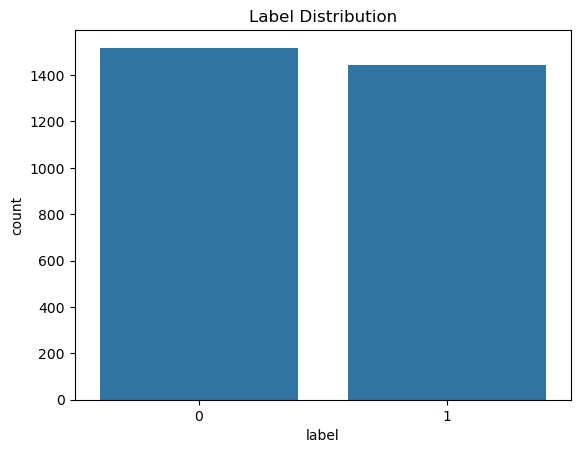

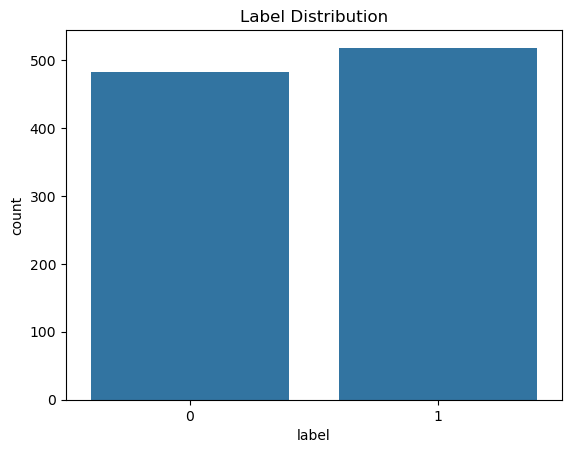

In [15]:
#文本标签数量分布
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
train_data=pd.read_csv('./data/train.tsv',sep='\t')
test_data=pd.read_csv('./data/dev.tsv',sep='\t')
print(train_data.head())
sns.countplot(x='label',data=train_data)
plt.title('Label Distribution')
plt.show()
sns.countplot(x='label',data=test_data)
plt.title('Label Distribution')
plt.show()

#分析文本标签分布的意义
#分析文本标签分布可以帮助我们了解数据集中的类别分布情况，判断是否存在类别不平衡问题，以及为后续的模型训练和评估提供参考。

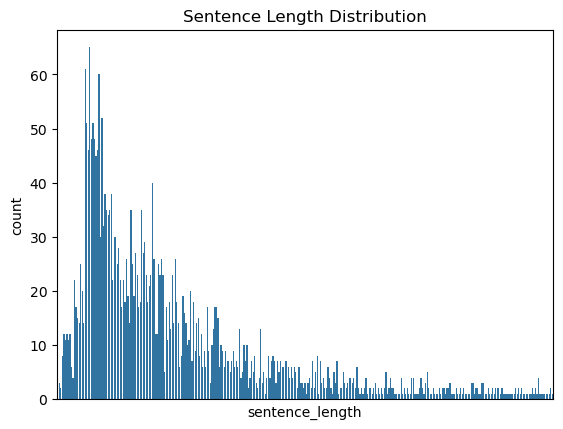

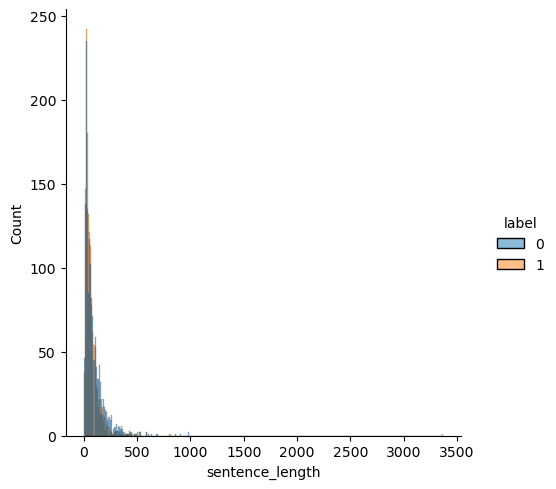

247753


In [25]:
#统计句子长度分布
#目的：了解数据集中句子长度的分布情况，判断是否需要进行文本截断或填充，以及为后续的模型设计提供参考。
train_data['sentence_length']=list(map(lambda x:len(x),train_data['sentence'])) #计算每个句子的长度，并将结果存储在新的列'sentence_length'中
train_data.head()
sns.countplot(x='sentence_length',data=train_data)
plt.title('Sentence Length Distribution')
plt.xticks([]) #去掉x轴的刻度标签，因为句子长度的取值范围可能较大，显示所有的刻度标签会导致图表过于拥挤和难以阅读
plt.show()

#曲线图
sns.displot(x='sentence_length',data=train_data,hue='label')
plt.show()


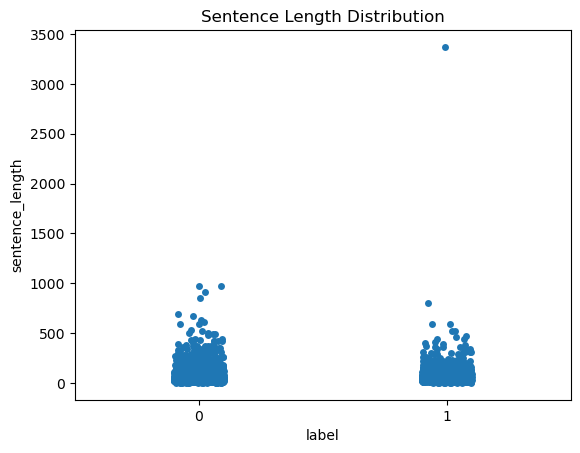

In [24]:
#句子长度散点分布
sns.stripplot(y='sentence_length',x='label',data=train_data)
plt.title('Sentence Length Distribution')
plt.show()

In [28]:
#获取样本单词总数
words=[jieba.lcut(w) for w in train_data['sentence'] ]
print(words)
unique_words=[]
for w in words:
    unique_words.extend(w)
unique_words=list(set(unique_words))
print(unique_words)
print(len(unique_words))


[['早餐', '不好', ',', '服务', '不', '到位', ',', '晚餐', '无', '西餐', ',', '早餐', '晚餐', '相同', ',', '房间', '条件', '不好', ',', '餐厅', '不', '分', '吸烟区', '.', '房间', '不分', '有', '无烟', '房', '.'], ['去', '的', '时候', ' ', ',', '酒店', '大厅', '和', '餐厅', '在', '装修', ',', '感觉', '大厅', '有点', '挤', '.', '由于', '餐厅', '装修', '本来', '该', '享受', '的', '早饭', ',', '也', '没有', '享受', '(', '他们', '是', '8', '点', '开始', '每个', '房间', '送', ',', '但是', '我', '时间', '来不及', '了', ')', '不过', '前台', '服务员', '态度', '好', '!'], ['有', '很', '长时间', '没有', '在', '西藏', '大厦', '住', '了', '，', '以前', '去', '北京', '在', '这里', '住', '的', '较', '多', '。', '这次', '住', '进来', '发现', '换', '了', '液晶电视', '，', '但', '网络', '不是', '很', '好', '，', '他们', '自己', '说', '是', '收费', '的', '原因', '造成', '的', '。', '其它', '还好', '。'], ['非常', '好', '的', '地理位置', '，', '住', '的', '是', '豪华', '海景房', '，', '打开', '窗户', '就', '可以', '看见', '栈桥', '和', '海景', '。', '记得', '很早以前', '也', '住', '过', '，', '现在', '重新', '装修', '了', '。', '总的来说', '比较满意', '，', '以后', '还会', '住'], ['交通', '很', '方便', '，', '房间', '小', '了', '一点', '，', '但是', '干净', '整洁', 

['好', '好', '好', '豪华', '重新', '方便', '小', '干净', '整洁', '高', '旧', '小', '不错', '热闹', '很好', '小', '便宜', '少', '好', '方便', '窄', '老', '近', '高', '好', '一般', '干净', '近', '便利', '不错', '连续', '旧', '好', '勤快', '好', '方便', '豪华', '不大', '干净', '不错', '好', '合适', '很大', '干净', '不错', '整洁', '新', '不错', '挺大', '大', '不错', '远', '不错', '挺好吃', '方便', '大', '好', '小', '热', '方便', '紧', '不错', '不错', '干净', '好', '一般', '简单', '好', '一般', '差', '小', '好', '不足', '不错', '大', '不错', '不错', '不错', '旧', '小', '干净', '良好', '好', '舒服', '敏感', '不错', '方便', '远', '一般', '不错', '不错', '方便', '干静', '宽敞', '好', '方便', '方便', '老', '方便', '大', '宽敞', '不错', '近', '方便', '差', '好', '难吃', '好', '小', '大', '豪华', '先进', '先进', '冷', '高', '好', '旧', '不错', '干净', '好', '好', '不错', '差', '惊喜', '小', '干净', '整洁', '不错', '愉快', '旧', '不错', '太软', '干净', '最大', '不错', '不错', '好', '不错', '远', '近', '最好', '好', '方便', '简单', '高', '不错', '早', '较大', '最好', '一般', '好', '旺', '浓烈', '小', '好', '舒畅', '最绝', '不错', '不错', '旧', '不错', '显贵', '小', '不错', '大', '爽快', '方便', '方便', '近', '不错', '很大', '旧', '高', '蓝', '蓝', '亲切', '好', '好', '细致', 

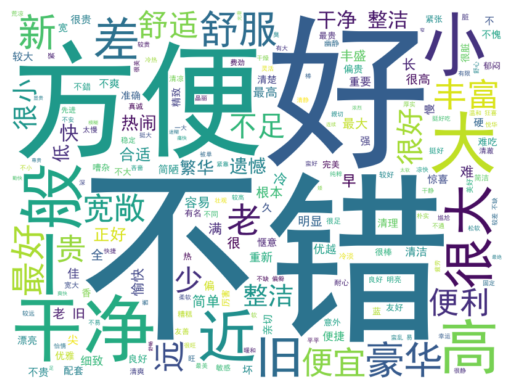

In [34]:
#获取训练集高频形容词词云
from wordcloud import WordCloud
import jieba.posseg as pseg #标注词性
import pandas as pd
train_data=pd.read_csv('./data/train.tsv',sep='\t')
#筛选正样本
positive_data=train_data[train_data['label']==1]['sentence']
# print(positive_data)
#筛选出形容词
adj=[]
for w in positive_data:
    words=pseg.lcut(w) #分词并标注词性,切分之后包含word和flag两个属性，word是词语，flag是词性
    for w in words:
        if w.flag=='a':
            adj.append(w.word)

print(adj)

#生成词云
#实例化词云
wordcloud=WordCloud(font_path='C:/Windows/Fonts/simhei.ttf',background_color='white',width=800,height=600) #font_path参数指定字体路径，background_color参数指定背景颜色，width和height参数指定词云图的宽度和高度，generate方法用于生成词云图，参数是一个字符串，包含了所有要显示的词语
keywords_string=' '.join(adj) #将形容词列表转换为一个字符串，使用空格分隔每个词语
wordcloud.generate(keywords_string) #生成词云图

#画图
plt.figure()
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()


In [42]:
#n-gram特征的理解
#n-gram特征是指在文本处理中，将连续的n个词语作为一个整体来进行分析和建模的特征表示方法。n-gram特征可以捕捉到文本中词语之间的局部上下文信息，从而提高模型的性能。
#例如，在句子“我喜欢自然语言处理”中，使用2-gram特征可以得到以下的2-gram特征：['我喜欢', '喜欢自然', '自然语言', '语言处理']。使用3-gram特征可以得到以下的3-gram特征：['我喜欢自然', '喜欢自然语言', '自然语言处理']。
#利用zip函数进行n-gram特征的生成
text='我喜欢自然语言处理,我觉得它很有趣。'
words=jieba.lcut(text)
print(words)
unique_words=list(set(words))
print(unique_words)
word_idx={w:i for i,w in enumerate(unique_words)}
print(word_idx)
idx=[word_idx[w] for w in words]
print(idx)
#zip函数用于将多个可迭代对象进行配对，生成一个新的可迭代对象，其中每个元素是由来自输入可迭代对象的对应元素组成的元组。
#生成n-gram特征
n=2
n_gram=list(set(zip(*[idx[i:] for i in range(n)]))) #*号的作用是将列表中的元素进行解包，zip函数会将解包后的元素进行配对，生成一个新的可迭代对象，其中每个元素是由来自输入可迭代对象的对应元素组成的元组。这里的输入可迭代对象是一个列表推导式，生成了n个列表，每个列表都是idx的一个切片，切片的起始位置依次向后移动一位，直到n-1位。最终生成的n_gram是一个包含了所有n-gram特征的列表，其中每个元素是一个元组，表示一个n-gram特征。
print(n_gram)

['我', '喜欢', '自然语言', '处理', ',', '我', '觉得', '它', '很', '有趣', '。']
['它', ',', '处理', '喜欢', '觉得', '很', '我', '。', '自然语言', '有趣']
{'它': 0, ',': 1, '处理': 2, '喜欢': 3, '觉得': 4, '很': 5, '我': 6, '。': 7, '自然语言': 8, '有趣': 9}
[6, 3, 8, 2, 1, 6, 4, 0, 5, 9, 7]
[(3, 8), (4, 0), (2, 1), (6, 4), (5, 9), (0, 5), (8, 2), (1, 6), (6, 3), (9, 7)]


In [52]:
#文本长度规范
#即统一句子长度
#这里利用pytorch进行文本长度规范,先截断后填充
from torch.nn.utils.rnn import pad_sequence

#截断
text1='我喜欢自然语言处理。'
text2='自然语言处理是人工智能的一个分支。'
text3='我觉得自然语言处理很有趣。'
texts=[text1,text2,text3]
words=[jieba.lcut(w) for w in texts]
print(words)
unique_words=[]
for w in words:
    unique_words.extend(w)
unique_words=list(set(unique_words))
print(unique_words)
word_idx={w:i for i,w in enumerate(unique_words)}
print(word_idx)
idx=[]
for w in words:
    tem=[word_idx[i] for i in w]
    idx.append(tem)
print(idx)

#截断
max_len=7
truncated_idx=[torch.tensor(i[:max_len]) for i in idx]
print(truncated_idx)

#填充
idx=pad_sequence(truncated_idx,batch_first=True,padding_value=0)
print(idx)




[['我', '喜欢', '自然语言', '处理', '。'], ['自然语言', '处理', '是', '人工智能', '的', '一个', '分支', '。'], ['我', '觉得', '自然语言', '处理', '很', '有趣', '。']]
['人工智能', '分支', '处理', '喜欢', '一个', '觉得', '很', '我', '。', '是', '自然语言', '的', '有趣']
{'人工智能': 0, '分支': 1, '处理': 2, '喜欢': 3, '一个': 4, '觉得': 5, '很': 6, '我': 7, '。': 8, '是': 9, '自然语言': 10, '的': 11, '有趣': 12}
[[7, 3, 10, 2, 8], [10, 2, 9, 0, 11, 4, 1, 8], [7, 5, 10, 2, 6, 12, 8]]
[tensor([ 7,  3, 10,  2,  8]), tensor([10,  2,  9,  0, 11,  4,  1]), tensor([ 7,  5, 10,  2,  6, 12,  8])]
tensor([[ 7,  3, 10,  2,  8,  0,  0],
        [10,  2,  9,  0, 11,  4,  1],
        [ 7,  5, 10,  2,  6, 12,  8]])


In [ ]:
#文本长度规范的意义
#文本长度规范的意义在于统一句子长度，使得模型能够处理不同长度的输入数据。通过截断和填充，可以将所有句子调整为相同的长度，从而方便模型的训练和推理。文本长度规范还可以帮助模型更好地捕捉句子中的关键信息，避免过长的句子带来的噪声和过短的句子带来的信息不足。此外，文本长度规范还可以提高模型的效率和性能，因为统一的输入长度可以更好地利用计算资源，并且可以减少模型的过拟合风险。


#回译数据增强法
#回译数据增强法是一种通过将文本翻译成另一种语言再翻译回原始语言来生成新的训练样本的方法。这种方法可以增加训练数据的多样性和丰富性，从而提高模型的泛化能力和性能。